## 0. Introduction

Australia’s population is constantly changing, but these changes are not the same in every region. Some areas grow as people move in for jobs and housing, while others lose residents to larger cities. At the same time, some regions are ageing, while others are growing younger because of new families and different settlement patterns.

For infrastructure planners, combining these two dimensions can lead to very different planning strategies:

| Mobility \ Ageing | Ageing | Stable | Growing Younger |
|---|---|---|---|
| **Moving Out** | **Revitalise**: Prevent "brain drain" and local decline. | **Investigate**: Why are people leaving a stable area? | **Supply**: Ensure enough housing for young people. |
| **Stable** | **Support**: Focus on aged care and local health. | **Maintain**: Monitor services; no major shift. | **Prepare**: Plan for schools and childcare. |
| **Moving In** | **Balance**: Attract young families for social health. | **Manage**: Ensure infrastructure keeps up with growth. | **Build**: High investment in family infrastructure. |

This project uses Australian Bureau of Statistics (ABS) data to classify SA2 regions. We aim to identify which socio-economic features best predict demographic shift, providing a more policy-relevant view of local change.


## 1. Framing & Dataset Selection


### 1-1 Research Question

How accurately can we predict a region's demographic shift, specifically ageing and migration, helping planners decide the infrastructure and policy strategy?


### 1-2 Project Methodology

We use a two-step approach to solve the classification task:
- *Label Creation (Calculated)*: We calculate both year-over-year percentage change in estimated resident population and year-over-year change in median age using ABS longitudinal data. We then assign each region-year observation to a mobility label (**Moving Out**, **Stable**, **Moving In**) and an ageing label (**Ageing**, **Age-Stable**, **Growing Younger**), then combine them into a 9-class profile.
- *Classification (Predictive)*: We build supervised models to predict these combined labels using current income and population characteristics.

## 2. Consider & Gather Data

### 2-1 Data Sources

We use two spreadsheets from the ABS *Data by Region, 2011–2025* release (https://www.abs.gov.au/methodologies/data-region-methodology/2011-24#data-downloads):

- **`14100DO0001_2011-25.xlsx`** — regional population and demographic variables (age structure, sex composition, population density, working-age population, etc.)
- **`14100DO0004_2011-25.xlsx`** — regional income variables (median income, income bracket distributions, etc.)

The longitudinal structure is essential: we derive both mobility and ageing labels from year-over-year changes in population and median age, then use income and population features to predict the combined 9-class profile.

The two datasets pass the CRAAP quality test:
- **Currency & Relevance**: Latest ABS Data by Region 2011–2025 release; ideal for measuring regional mobility and demographic change.
- **Authority & Accuracy**: Sourced from the Australian Bureau of Statistics (ABS), the national standard for Australian demographic data.
- **Purpose**: Objective, public-research data designed for regional analysis and policy planning.


In [19]:
# ── Libraries ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ── File paths ──────────────────────────────────────────────────────────────
population_file = '14100DO0001_2011-25.xlsx'
income_file     = '14100DO0004_2011-25.xlsx'

# ── 1. Sheet names ──────────────────────────────────────────────────────────
pop_sheets    = pd.ExcelFile(population_file).sheet_names
income_sheets = pd.ExcelFile(income_file).sheet_names
print('Acquiring data from ABS...')
print(f'Population file -> {len(pop_sheets)} sheets : {pop_sheets}')
print(f'Income file     -> {len(income_sheets)} sheets : {income_sheets}')

# ── 2. Shape of every Table sheet ──────────────────────────────────────────
pop_table_sheets    = [s for s in pop_sheets    if s.startswith('Table')]
income_table_sheets = [s for s in income_sheets if s.startswith('Table')]

# ── 3. Load and combine all Table sheets ───────────────────────────────────
# not clean here because we need to calculate the dirty rate
def load_all_tables(filepath, table_sheets):
    dfs = []
    for sheet in table_sheets:
        df = pd.read_excel(filepath, sheet_name=sheet, header=6, na_values=['-', '..', ' ', 'np', 'n.p.','\u2013'])
        df['source'] = sheet
        df['t2']     = (sheet == 'Table 2')
        df['t3']     = (sheet == 'Table 3')
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

population_raw = load_all_tables(population_file, pop_table_sheets)
income_raw     = load_all_tables(income_file,     income_table_sheets)


Acquiring data from ABS...
Population file -> 4 sheets : ['Contents', 'Table 1', 'Table 2', 'Table 3']
Income file     -> 4 sheets : ['Contents', 'Table 1', 'Table 2', 'Table 3']


### 2-2 Dataset Justification

The dataset meets the project requirements as follows:


In [20]:
# ── Create popul_df and income_df ──────────────────────────────────────────
# population_raw / income_raw already loaded above (all Table sheets combined).
# R equivalent: rename(), mutate(across(..., as.numeric))

popul_df  = population_raw.copy()
income_df = income_raw.copy()

# Identify non-identifier columns
id_cols       = ['Code', 'Label', 'Year', 'source', 't2', 't3']
data_cols_pop = [c for c in popul_df.columns  if c not in id_cols]
data_cols_inc = [c for c in income_df.columns if c not in id_cols]

# Convert data columns to numeric
# R equivalent: mutate(across(all_of(data_cols), as.numeric))
popul_df[data_cols_pop]  = popul_df[data_cols_pop].apply(pd.to_numeric, errors='coerce')
income_df[data_cols_inc] = income_df[data_cols_inc].apply(pd.to_numeric, errors='coerce')

# Outlier rate: Tukey IQR fence 
def iqr_outlier_rate(df, cols):
    q1  = df[cols].quantile(0.25)
    q3  = df[cols].quantile(0.75)
    iqr = q3 - q1
    is_out      = (df[cols] < q1 - 1.5 * iqr) | (df[cols] > q3 + 1.5 * iqr)
    total_valid = df[cols].notna().values.sum()
    return is_out.values.sum() / total_valid if total_valid > 0 else float('nan')

pop_outlier = iqr_outlier_rate(popul_df,  data_cols_pop)
inc_outlier = iqr_outlier_rate(income_df, data_cols_inc)

# ── Summary table ───────────────────────────────────────────────────────────
# R equivalent: tibble(nrow=..., ncol=..., missing=mean(is.na(.)))
pop_miss = popul_df[data_cols_pop].isna().values.mean()
inc_miss = income_df[data_cols_inc].isna().values.mean()

summary = pd.DataFrame({
    'DataFrame'            : ['popul_df', 'income_df'],
    'Rows'                 : [f'{len(popul_df):,}',  f'{len(income_df):,}'],
    'Total columns'        : [len(popul_df.columns),  len(income_df.columns)],
    'Data columns'         : [len(data_cols_pop),      len(data_cols_inc)],
    'Overall missing %'    : [f'{pop_miss:.1%}',       f'{inc_miss:.1%}'],
    'Potential outliers %' : [f'{pop_outlier:.1%}',    f'{inc_outlier:.1%}'],
})
print(summary.to_string(index=False))


DataFrame   Rows  Total columns  Data columns Overall missing % Potential outliers %
 popul_df 31,370            166           160             44.6%                 9.2%
income_df 38,247             59            53             67.5%                 7.2%


more than 3 requirements are met:
- **Large**: 31k+ population rows and 38k+ income rows across all geographic levels; SA2-level alone exceeds 10,000 observations.
- **Messy**: ~50% overall missing value rate and ~8% potential outliers in non-missing values.
- **Complex**: 163 population columns and 56 income columns combined (>100 threshold).
- **Complex**: rows span multiple geographic levels (National, State, SA4, SA3, LGA, SA2), which overlap hierarchically
- **Integration**: data is from two source.

For our mobility analysis we prefer avoiding information overlap and retaining only one geo level, So we do the screening on geo level first:


/var/folders/rq/dq6k05k570l01_l2vrdmp3440000gn/T/ipykernel_56687/874865329.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  popul_df['geo_level']  = popul_df.apply(classify_geo,  axis=1)


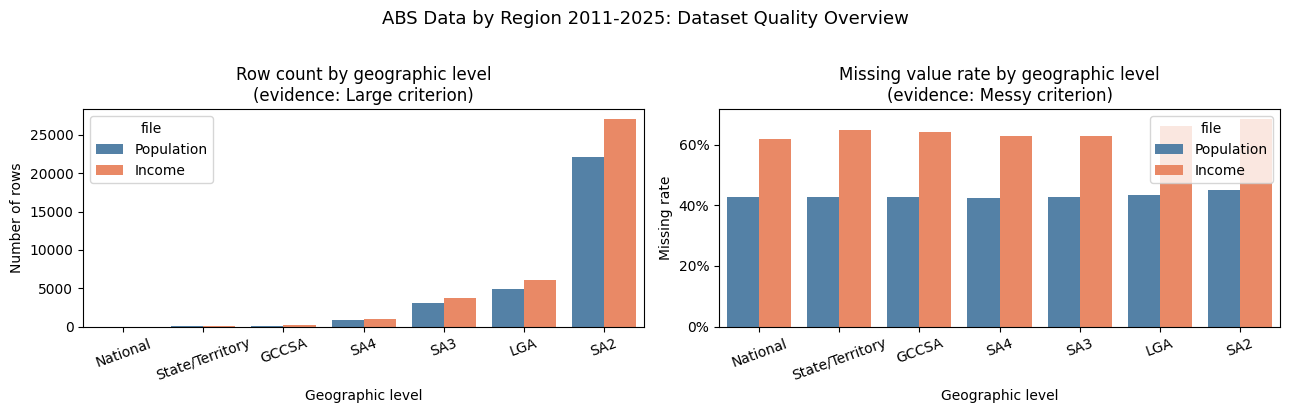

In [21]:
# ── Geographic level breakdown: row count + missing rate ───────────────────

def classify_geo(row):
    s  = str(row['Code']).strip()
    t2 = row['t2']
    t3 = row['t3']
    if s == 'AUS':                                return 'National'
    elif s.isdigit() and len(s) == 1:             return 'State/Territory'
    elif s.isdigit() and len(s) == 3 and t3:      return 'Remote'
    elif s.isdigit() and len(s) == 3:             return 'SA4'
    elif len(s) == 5 and not s.isdigit():         return 'GCCSA'
    elif s.isdigit() and len(s) == 5 and t2:      return 'LGA'
    elif s.isdigit() and len(s) == 5 and not t2:  return 'SA3'
    elif s.isdigit() and len(s) == 9:             return 'SA2'
    else:                                         return 'Other'

popul_df['geo_level']  = popul_df.apply(classify_geo,  axis=1)
income_df['geo_level'] = income_df.apply(classify_geo, axis=1)

# Row count per geo level
# R equivalent: count(df, geo_level)
pop_geo_counts    = popul_df.groupby('geo_level').size().rename('rows')
income_geo_counts = income_df.groupby('geo_level').size().rename('rows')

# Missing rate per geo level (across all data columns)
# R equivalent: group_by(geo_level) |> summarise(across(..., ~mean(is.na(.))))
pop_missing = (popul_df.groupby('geo_level')[data_cols_pop]
               .apply(lambda df: df.isna().values.mean())
               .rename('missing_rate'))
inc_missing = (income_df.groupby('geo_level')[data_cols_inc]
               .apply(lambda df: df.isna().values.mean())
               .rename('missing_rate'))

# ── Plot ────────────────────────────────────────────────────────────────────
geo_order = ['National', 'State/Territory', 'GCCSA', 'SA4', 'SA3', 'LGA', 'SA2']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

row_df = pd.DataFrame({
    'geo_level' : geo_order * 2,
    'file'      : ['Population'] * len(geo_order) + ['Income'] * len(geo_order),
    'rows'      : [pop_geo_counts.get(g, 0) for g in geo_order] +
                  [income_geo_counts.get(g, 0) for g in geo_order]
})
sns.barplot(data=row_df, x='geo_level', y='rows', hue='file',
            palette=['steelblue', 'coral'], ax=axes[0])
axes[0].set_title('Row count by geographic level\n(evidence: Large criterion)')
axes[0].set_xlabel('Geographic level')
axes[0].set_ylabel('Number of rows')
axes[0].tick_params(axis='x', rotation=20)

miss_df = pd.DataFrame({
    'geo_level'    : geo_order * 2,
    'file'         : ['Population'] * len(geo_order) + ['Income'] * len(geo_order),
    'missing_rate' : [pop_missing.get(g, float('nan')) for g in geo_order] +
                     [inc_missing.get(g, float('nan')) for g in geo_order]
})
sns.barplot(data=miss_df, x='geo_level', y='missing_rate', hue='file',
            palette=['steelblue', 'coral'], ax=axes[1])
axes[1].set_title('Missing value rate by geographic level\n(evidence: Messy criterion)')
axes[1].set_xlabel('Geographic level')
axes[1].set_ylabel('Missing rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('ABS Data by Region 2011-2025: Dataset Quality Overview', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


SA2 is the preferred geographic level for this project: it provides sufficient granularity to capture local mobility change while having enough observations (>10,000 labelled rows after year-on-year differencing) for reliable classification. We filter both cleaned dataframes to SA2 and carry forward only these rows for all subsequent steps.


In [22]:
# Filter to SA2 level using geo_level column assigned above
# R equivalent: filter(geo_level == "SA2")
population_sa2 = popul_df[popul_df['geo_level'] == 'SA2'].copy()
income_sa2     = income_df[income_df['geo_level'] == 'SA2'].copy()

print(f"population_sa2 : {len(population_sa2):,} rows")
print(f"income_sa2     : {len(income_sa2):,} rows")


population_sa2 : 22,086 rows
income_sa2     : 26,994 rows


## 3. Exploratory Data Analysis (EDA)


### 3-1 Univariate Analysis

The high overall missing rate (~40–65%) observed in Section 2 partially reflects ABS suppression of small counts — a value is withheld when it is too small to publish, not because it is truly absent. For percentage breakdown columns (age group shares, income bracket shares), a suppressed cell effectively means the proportion rounds to zero.

We therefore distinguish two types of column:
- **Key columns** — those whose name contains *"total"* — which serve as summary measures and should be populated for all valid SA2 observations.
- **Breakdown columns** — all others — where NaN can legitimately represent zero.

The approach: identify key columns, compute their missing rate, and drop rows where more than 50% of key columns are NaN. Then impute 0 into remaining NaN cells across breakdown columns.


#### 3-1-1 refine column name

In [23]:
# code here

#### 3-1-2 missing row remove

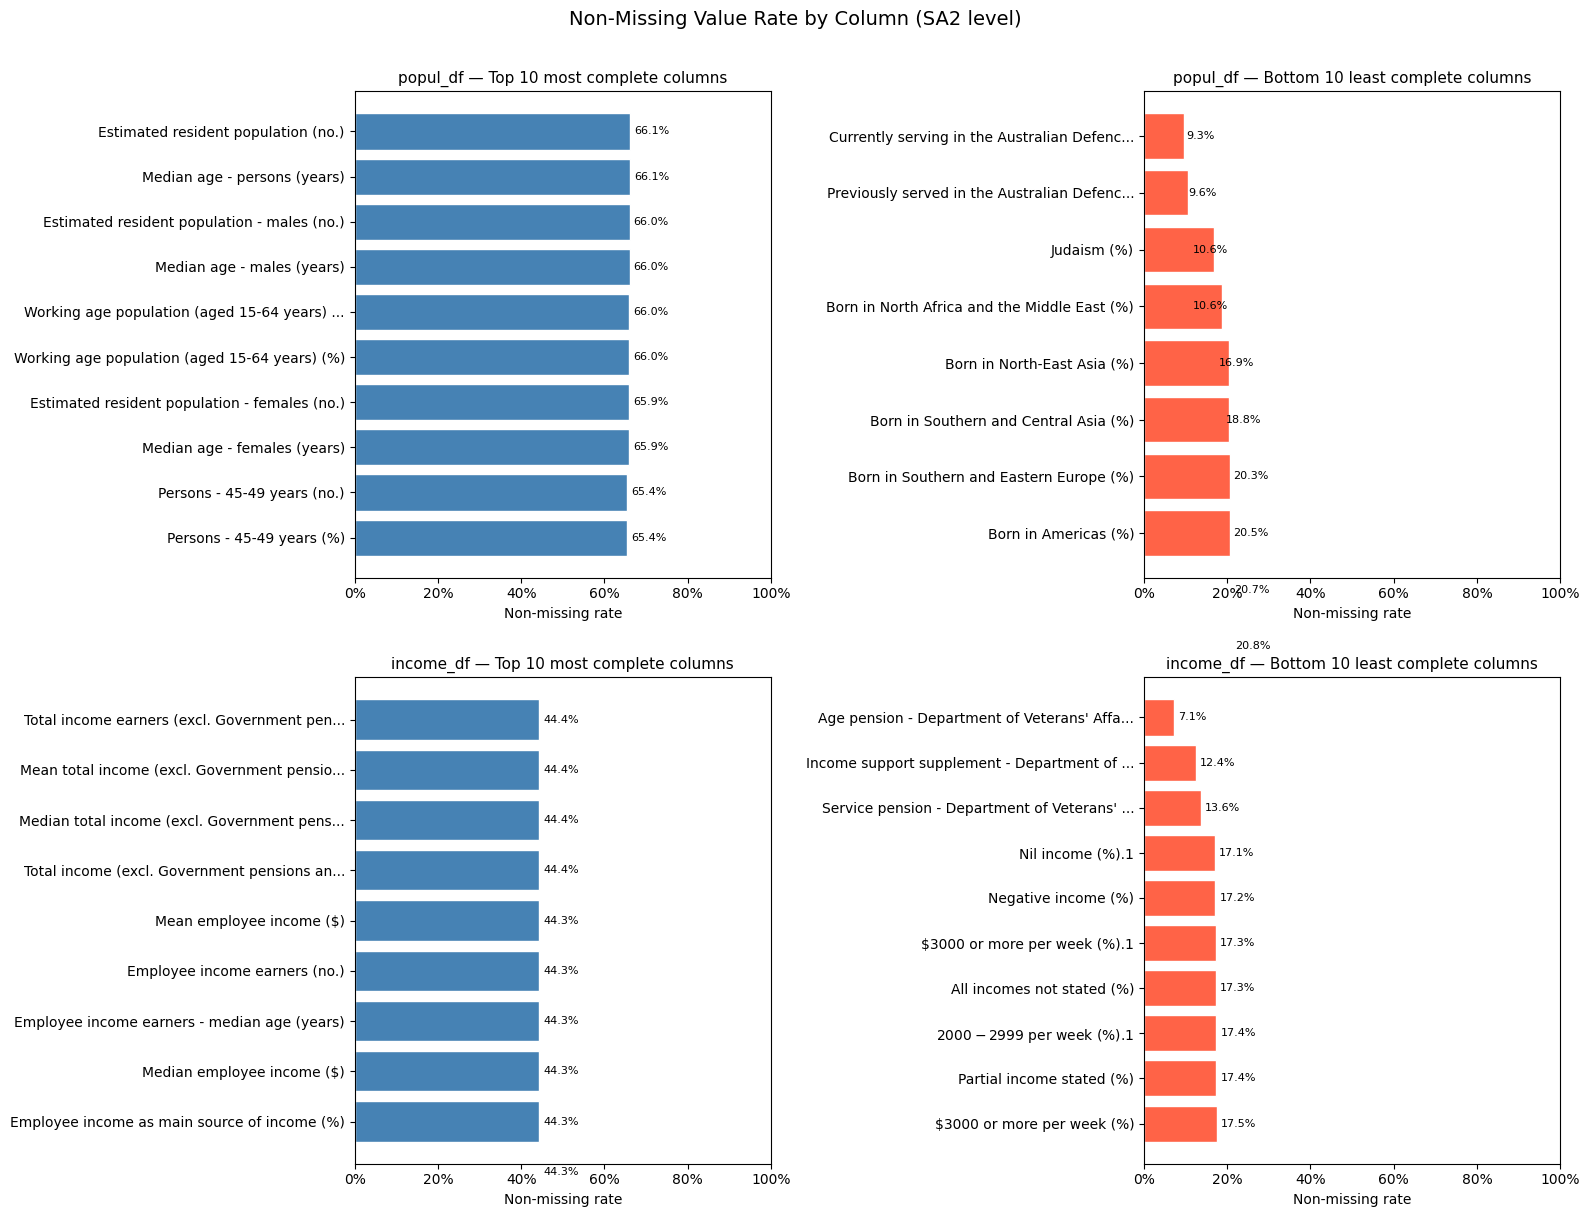

In [24]:
# ── Non-missing rate per column ─────────────────────────────────────────────
# non-missing rate = proportion of rows where the value is NOT NaN
# sorted descending: top rows = most complete columns
# R equivalent: colMeans(!is.na(df)) |> sort(decreasing=TRUE)
pop_nonmiss = popul_df[data_cols_pop].notna().mean().sort_values(ascending=False)
inc_nonmiss = income_df[data_cols_inc].notna().mean().sort_values(ascending=False)

pop_top10    = pop_nonmiss.head(10)
pop_bottom10 = pop_nonmiss.tail(10).sort_values(ascending=True)   # worst first for readability
inc_top10    = inc_nonmiss.head(10)
inc_bottom10 = inc_nonmiss.tail(10).sort_values(ascending=True)

# Truncate long column names for display (ABS names can be very long)
def short_label(name, max_len=45):
    return name if len(name) <= max_len else name[:max_len - 3] + '...'

# ── 4 figures in a 2x2 grid ─────────────────────────────────────────────────
# Horizontal bar charts because column names are long
# R equivalent: ggplot + geom_col() + coord_flip() + facet_wrap()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Non-Missing Value Rate by Column (SA2 level)', fontsize=14, y=1.01)

panels = [
    (axes[0, 0], pop_top10,    'popul_df — Top 10 most complete columns',   'steelblue'),
    (axes[0, 1], pop_bottom10, 'popul_df — Bottom 10 least complete columns','tomato'),
    (axes[1, 0], inc_top10,    'income_df — Top 10 most complete columns',  'steelblue'),
    (axes[1, 1], inc_bottom10, 'income_df — Bottom 10 least complete columns','tomato'),
]

for ax, data, title, colour in panels:
    labels = [short_label(n) for n in data.index]
    ax.barh(labels, data.values, color=colour, edgecolor='white')
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.set_xlabel('Non-missing rate')
    ax.set_title(title, fontsize=11)
    ax.invert_yaxis()   # highest bar at top
    # Annotate bars with the exact percentage
    for i, v in enumerate(data.values):
        ax.text(v + 0.01, i, f'{v:.1%}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


We select only column names containing *"total"* as key columns and compute their missing rate. Rows where more than 50% of key columns are NaN are considered too incomplete and dropped. This ensures downstream analysis is not distorted by rows that contain too little usable summary data.


In [25]:
# ── Key columns: names containing 'total' ──────────────────────────────────

id_cols_full  = ['Code', 'Label', 'Year', 'source', 't2', 't3', 'geo_level']

key_cols_pop = [c for c in population_sa2.columns
                if 'total' in c.lower() and c not in id_cols_full]
key_cols_inc = [c for c in income_sa2.columns
                if 'total' in c.lower() and c not in id_cols_full]

# Missing rate on key columns only
print("\n── Missing rate on key columns ─────────────────────────")
print("\nPopulation:")
print(population_sa2[key_cols_pop].isna().mean().map('{:.1%}'.format).to_string())
print("\nIncome:")
print(income_sa2[key_cols_inc].isna().mean().map('{:.1%}'.format).to_string())

# Drop rows where more than 50% of key columns are NaN
pop_key_missing_share = population_sa2[key_cols_pop].isna().mean(axis=1)
inc_key_missing_share = income_sa2[key_cols_inc].isna().mean(axis=1)

population_sa2_clean = population_sa2.loc[pop_key_missing_share <= 0.5].copy()
income_sa2_clean     = income_sa2.loc[inc_key_missing_share <= 0.5].copy()

print(f"\nPopulation SA2 : {len(population_sa2):,} → {len(population_sa2_clean):,} rows  (dropped {len(population_sa2)-len(population_sa2_clean):,})")
print(f"Income SA2     : {len(income_sa2):,} → {len(income_sa2_clean):,} rows  (dropped {len(income_sa2)-len(income_sa2_clean):,})")



── Missing rate on key columns ─────────────────────────

Population:
Total fertility rate (births per female) (rate)    37.1%
Total born overseas (no.)                          78.5%
Total born overseas (%)                            78.5%

Income:
Median equivalised total household income (weekly) ($)                                  73.3%
Total employee income ($m)                                                              55.6%
Total own unincorporated business income ($m)                                           56.4%
Total investment income ($m)                                                            56.3%
Total superannuation and annuity income ($m)                                            56.9%
Total income earners (excl. Government pensions and allowances) (no.)                   55.5%
Total income earners (excl. Government pensions and allowances) - median age (years)    55.5%
Total income (excl. Government pensions and allowances) ($m)                            55.

After removing rows with too much missingness in the key columns, remaining NaN cells in breakdown columns are imputed as 0. This is defensible because ABS suppresses values that are too small to publish — for our percentage columns, this is equivalent to a share of effectively zero.


In [26]:
# ── Impute NaN → 0 in breakdown data columns ───────────────────────────────
# Suppressed ABS values (small counts/percentages withheld for privacy)
# are effectively zero for our percentage-based mobility analysis.
# R equivalent: mutate(across(all_of(data_cols), ~replace_na(., 0)))

id_cols_full      = ['Code', 'Label', 'Year', 'source', 't2', 't3', 'geo_level']
data_cols_sa2_pop = [c for c in population_sa2_clean.columns if c not in id_cols_full]
data_cols_sa2_inc = [c for c in income_sa2_clean.columns     if c not in id_cols_full]

population_sa2_clean[data_cols_sa2_pop] = population_sa2_clean[data_cols_sa2_pop].fillna(0)
income_sa2_clean[data_cols_sa2_inc]     = income_sa2_clean[data_cols_sa2_inc].fillna(0)

print("Remaining NaN after imputation:")
print(f"  population_sa2_clean : {population_sa2_clean[data_cols_sa2_pop].isna().sum().sum()}")
print(f"  income_sa2_clean     : {income_sa2_clean[data_cols_sa2_inc].isna().sum().sum()}")


Remaining NaN after imputation:
  population_sa2_clean : 0
  income_sa2_clean     : 0


#### 3-1-3 outlier detection

#### 3-1-4 processing for data merging

although data look across 14 years, but few year is missing data

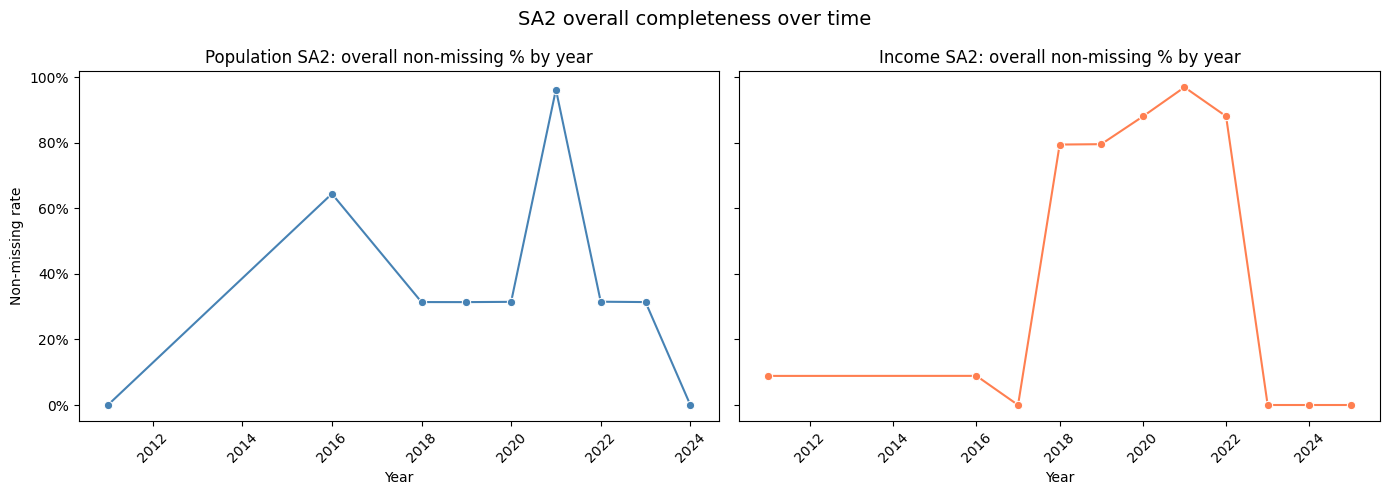

In [27]:
# ── Overall non-missing value % by year in SA2 ──────────────────────────────
# R equivalent: group_by(Year) |> summarise(overall_non_missing = mean(!is.na(across(...))))

# Reuse key_cols_pop and key_cols_inc defined above.

pop_year_nonmiss = (
    population_sa2.groupby('Year')[key_cols_pop]
    .apply(lambda df: 1 - df.isna().values.mean())
    .rename('non_missing_rate')
    .reset_index()
)

inc_year_nonmiss = (
    income_sa2.groupby('Year')[key_cols_inc]
    .apply(lambda df: 1 - df.isna().values.mean())
    .rename('non_missing_rate')
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.lineplot(data=pop_year_nonmiss, x='Year', y='non_missing_rate', marker='o', ax=axes[0], color='steelblue')
axes[0].set_title('Population SA2: overall non-missing % by year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Non-missing rate')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=inc_year_nonmiss, x='Year', y='non_missing_rate', marker='o', ax=axes[1], color='coral')
axes[1].set_title('Income SA2: overall non-missing % by year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('SA2 overall completeness over time', fontsize=14)
plt.tight_layout()
plt.show()

As a data integrity check, we verify that percentage breakdown columns sum to approximately 100 per row. Age group percentage columns (for Persons) and income bracket percentage columns should each sum to ~100. Rows that fall well outside this range indicate residual data quality issues.


In [28]:
# ── Sum check: percentage columns should sum to ~100 per row ───────────────
# Validates data integrity after imputation.
# R equivalent: rowSums(select(df, ends_with("(%)")))

# Age group % for Persons
age_pct_cols = [c for c in population_sa2_clean.columns
                if 'Persons' in c and 'years' in c and '(%)' in c]
# Income bracket %
inc_pct_cols = [c for c in income_sa2_clean.columns
                if 'per week (%)' in c.lower()]

print("── Age group % sum check (Persons, should be ~100) ──────")
if age_pct_cols:
    s = population_sa2_clean[age_pct_cols].sum(axis=1)
    print(f"  Columns : {len(age_pct_cols)}")
    print(f"  Mean    : {s.mean():.2f}    Min : {s.min():.2f}    Max : {s.max():.2f}")
    print(f"  Rows outside [95, 105] : {((s < 95) | (s > 105)).sum():,}")
else:
    print("  No matching columns found")

print("\n── Income bracket % sum check (should be ~100) ──────────")
if inc_pct_cols:
    s2 = income_sa2_clean[inc_pct_cols].sum(axis=1)
    print(f"  Columns : {len(inc_pct_cols)}")
    print(f"  Mean    : {s2.mean():.2f}    Min : {s2.min():.2f}    Max : {s2.max():.2f}")
    print(f"  Rows outside [95, 105] : {((s2 < 95) | (s2 > 105)).sum():,}")
else:
    print("  No matching columns found")


── Age group % sum check (Persons, should be ~100) ──────
  Columns : 17
  Mean    : 49.14    Min : 0.00    Max : 100.30
  Rows outside [95, 105] : 2,421

── Income bracket % sum check (should be ~100) ──────────
  Columns : 10
  Mean    : 34.56    Min : 0.00    Max : 251.90
  Rows outside [95, 105] : 11,994


### 3-2 Bivariate Analysis

Since our target variable (mobility × ageing profile) does not exist in the raw data, we engineer it here. We merge the SA2 population and income datasets on region code and year, then compute both year-over-year percentage change in estimated resident population and year-over-year change in median age per SA2 region.

The mobility rules are:

| Mobility label | Rule |
|---|---|
| `moving_out` | Population change < -x% YoY |
| `stable` | Change between -x% and x% YoY |
| `moving_in` | Population change > x% YoY |

The ageing rules are:

| Ageing label | Rule |
|---|---|
| `ageing` | Median age increased by > x years YoY |
| `age_stable` | Change within ±x years |
| `growing_younger` | Median age decreased by > x years YoY |

We then combine the two dimensions into a 9-class profile and examine which income and demographic characteristics differ across these joint classes.


In [29]:
###


The boxplots above show feature distributions by the combined 9-class profile. Features that show clearly separated distributions across these joint labels are strong candidates as predictors in the classification models. We look for variables where classes such as *moving_out x ageing* differ visibly from *moving_in x growing_younger* in terms of income share, population density, working-age proportion, or age structure.

For planning, the matrix is more informative than either dimension alone. For example, *moving_out x ageing* may signal brain drain and a need for local support services, *stable x age_stable* may suggest service maintenance and retention strategies, and *moving_in x growing_younger* may indicate pressure for schools, childcare, housing, and family infrastructure.


3-3 Data Visualisation

In [30]:
### 